## Model Assumptions

Use the model specified below and check the following assumptions:

1. Assess Linearity & fix if necessary
2. Assess Independence of Errors -- if violated stop here
3. Assess Normality of Errors & fix if necessary
4. Assess Multicollinearity & fix if necessary
5. Assess Equal Variance of Errors & fix if necessary
6. Determine if any influential points are in our data and fix if necessary

In [1]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import numpy as np

computers = pd.read_csv("../Data/Computers.csv")

computers.tail()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
6254,1690,100,528,8,15,no,no,yes,39,35
6255,2223,66,850,16,15,yes,yes,yes,39,35
6256,2654,100,1200,24,15,yes,no,yes,39,35
6257,2195,100,850,16,15,yes,no,yes,39,35
6258,2490,100,850,16,17,yes,no,yes,39,35


### EDA

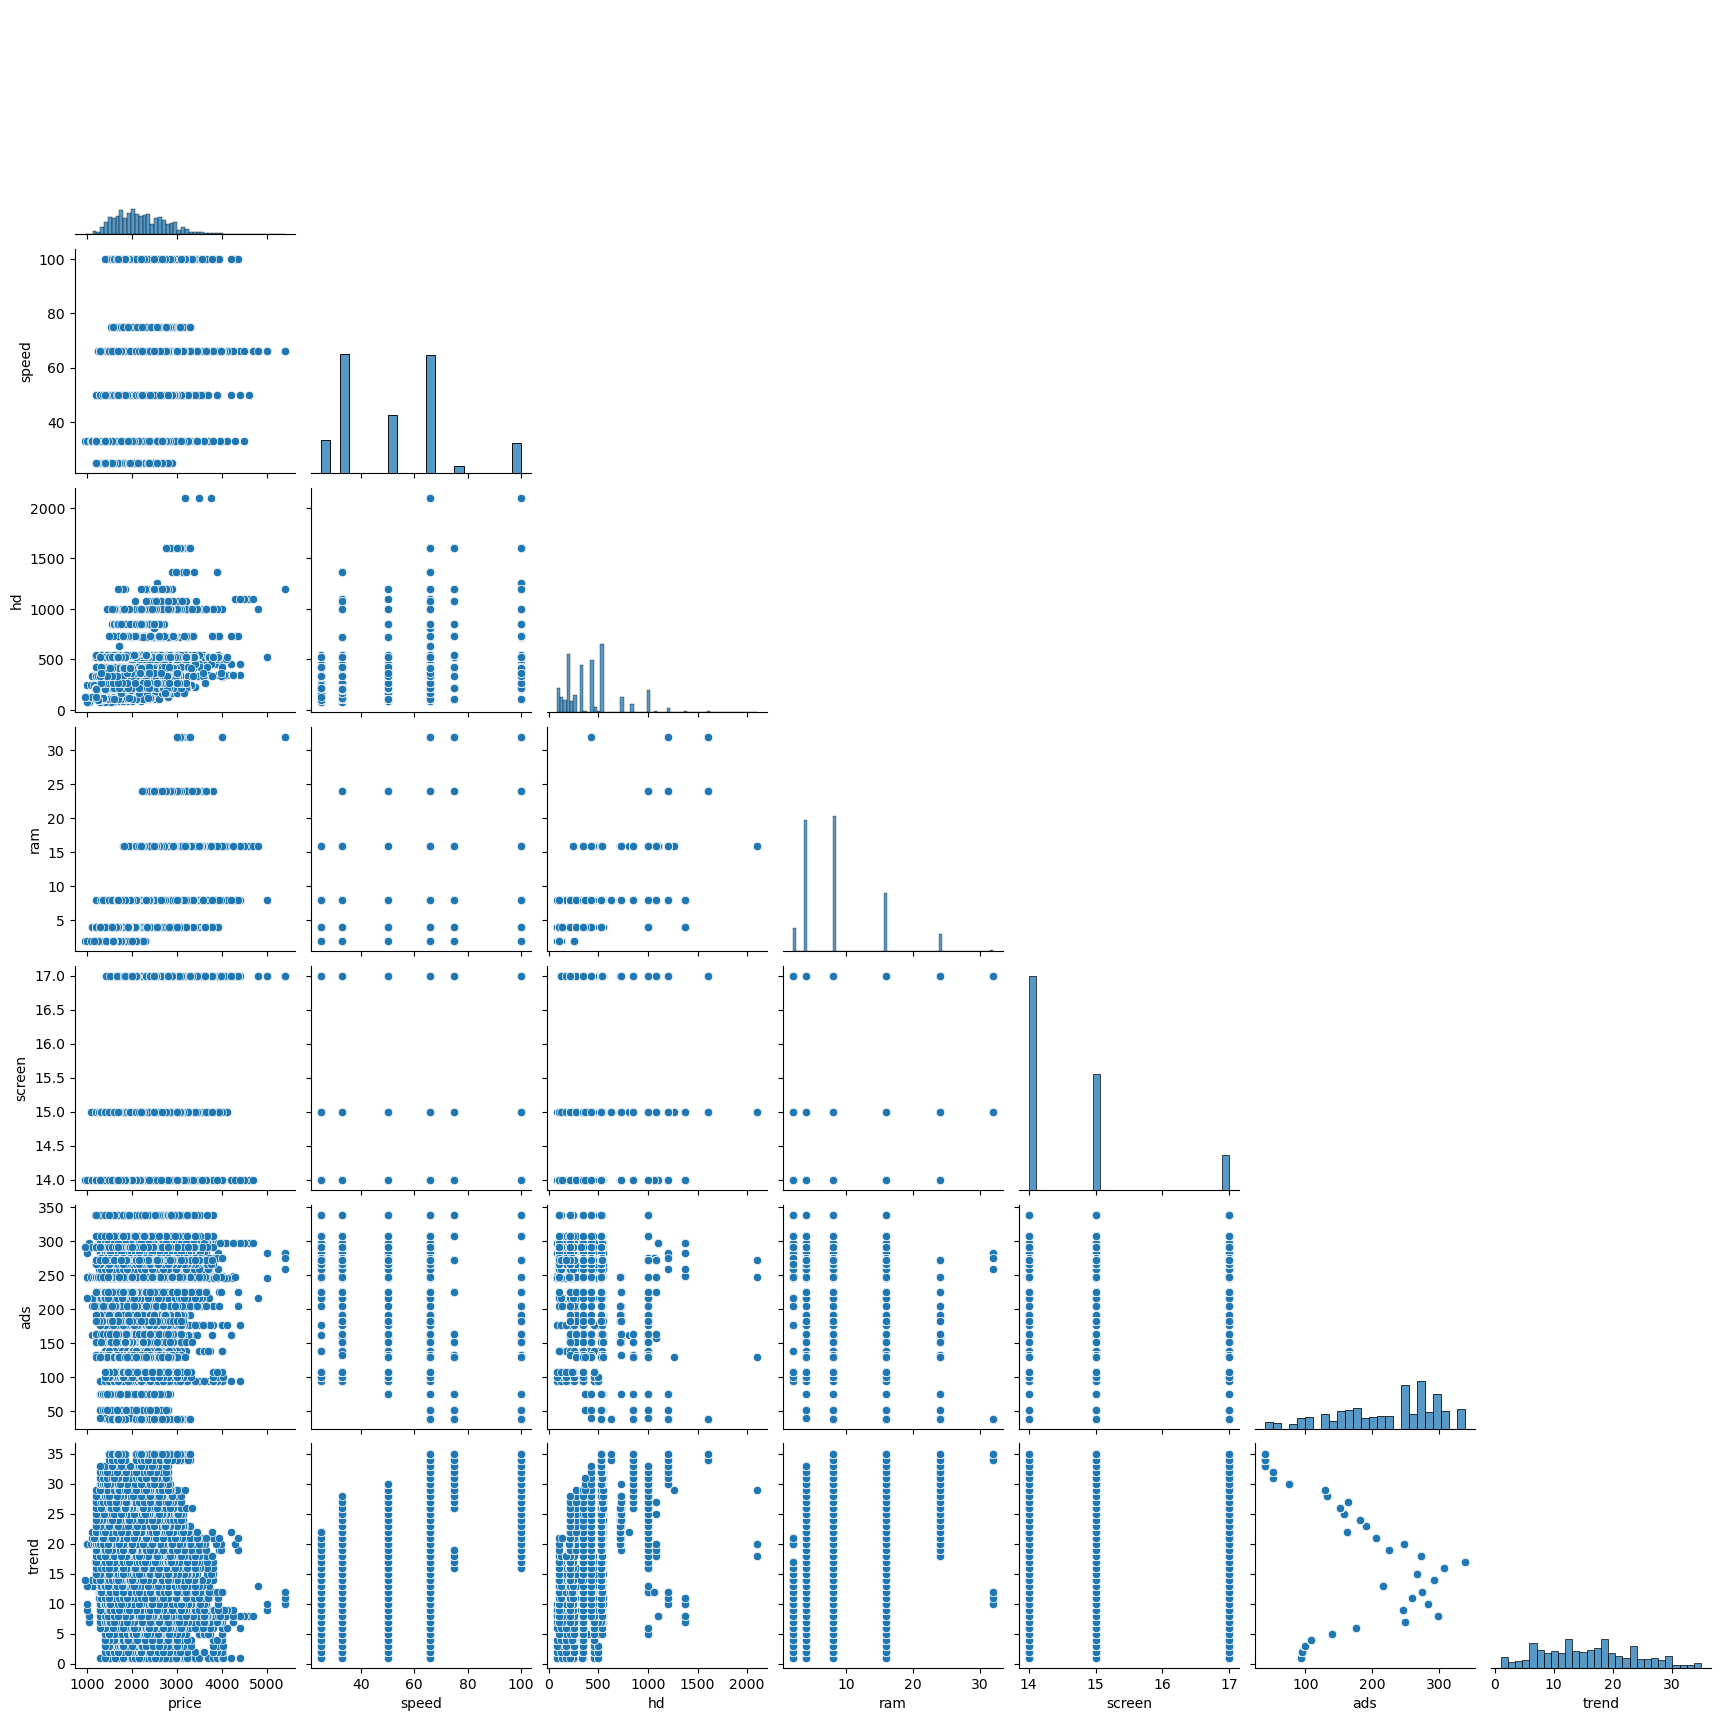

In [3]:
sns.pairplot(computers, corner=True)

<Axes: xlabel='ram'>

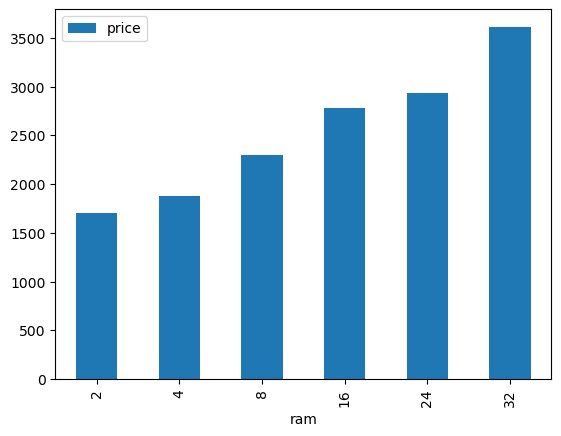

In [11]:
computers.groupby('ram').agg({'price': 'mean'}).plot.bar()

### Model Fitting

In [5]:
cols = ["ram", "speed", "hd", "screen", "ads", "trend"]

X = sm.add_constant(computers[cols])
y = computers["price"]

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     2580.
Date:                Fri, 13 Dec 2024   Prob (F-statistic):               0.00
Time:                        01:17:54   Log-Likelihood:                -44817.
No. Observations:                6259   AIC:                         8.965e+04
Df Residuals:                    6252   BIC:                         8.969e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -246.6755     66.371     -3.717      0.000    -376.785    -116.566
ram           47.3870      1.188     39.899      0.000      45.059      49.715
speed          8.8939      0.209     42.590      0.000       8.485       9.303
hd             0.7088      0.031     22.932      0.000       0.648       0.769
screen       126.7024      4.521     28.022      0.000     117.839     135.566
ads            0.9697      0.057     17.099      0.000       0.859       1.081
trend        -47.0820      0.676    -69.660      0.000     -48.407     -45.757
==============================================================================
Omnibus:                     1407.073   Durbin-Watson:                   1.948
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3902.981
Skew:                           1.187   Prob(JB):                         0.00
Kurtosis:                       6.054   Cond. No.                     8.89e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.89e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

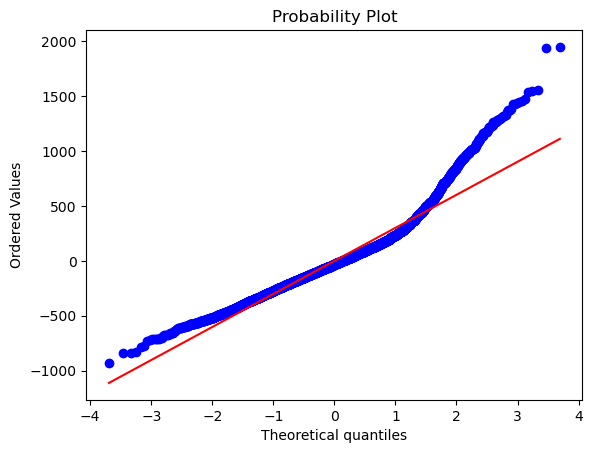

In [15]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(model.resid, dist='norm', plot=plt);

In [7]:
### Residual plotter helper function

def residual_analysis_plots(model):
    
    import scipy.stats as stats
    import matplotlib.pyplot as plt
    
    predictions = model.predict()
    residuals = model.resid
    
    fig, ax = plt.subplots(1, 2, sharey="all", figsize=(10, 6))
    
    sns.scatterplot(x=predictions, y=residuals, ax=ax[0], alpha=.3)
    ax[0].set_title("Residual Plot")
    ax[0].set_xlabel("Prediction")
    ax[0].set_ylabel("Residuals")
    
    stats.probplot(residuals, dist="norm", plot=ax[1])
    ax[1].set_title("Normal Q-Q Plot")   

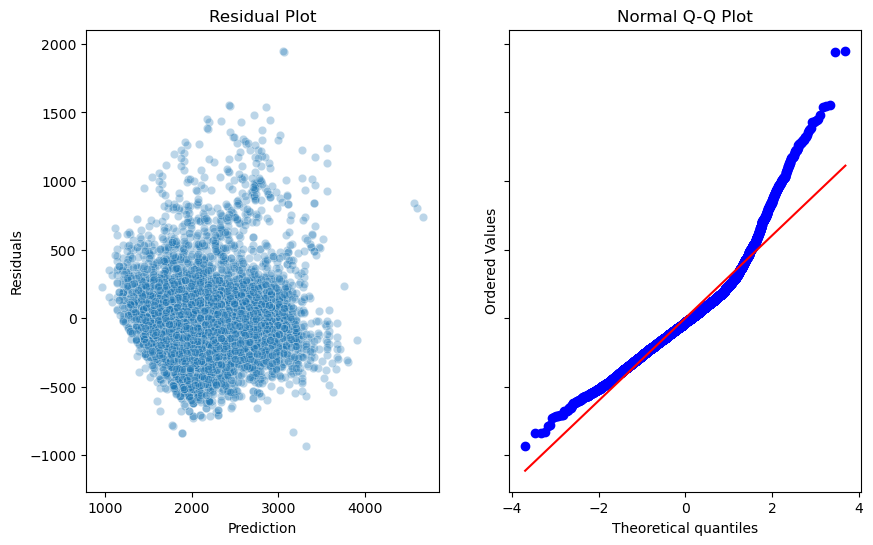

In [17]:
residual_analysis_plots(model);

In [35]:
computers = computers.assign(
    ram2 = computers['ram'] ** 2,
    hd2 = computers['hd'] ** 2,
    premium_flag = np.where(computers['premium'] == 'yes', 1, 0),
    multi_flag = np.where(computers['multi'] == 'yes', 1, 0),
    cd_flag = np.where(computers['multi'] == 'yes', 1, 0),
    trend2 =  computers['trend'] ** 2
)

cols = [
    'ram',
    # 'ram2',
    'speed',
    'hd',
    # 'hd2',
    'screen',
    'ads',
    'trend',
    # 'trend2',
    'premium_flag',
    'multi_flag',
    'cd_flag'
]

X = sm.add_constant(computers[cols])
# y = computers["price"]

y = np.log(computers['price'])

model = sm.OLS(y, X).fit()

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     2743.
Date:                Fri, 13 Dec 2024   Prob (F-statistic):               0.00
Time:                        02:05:38   Log-Likelihood:                 4313.5
No. Observations:                6259   AIC:                            -8609.
Df Residuals:                    6250   BIC:                            -8548.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.8059      0.027    256.558      0.000       6.754       6.858
ram              0.0218      0.000     46.961      0.000       0.021       0.023
speed            0.0043   8.16e-05     52.572      0.000       0.004       0.004
hd               0.0004   1.21e-05     29.576      0.000       0.000       0.000
screen           0.0543      0.002     30.768      0.000       0.051       0.058
ads              0.0003   2.23e-05     14.324      0.000       0.000       0.000
trend           -0.0229      0.000    -84.560      0.000      -0.023      -0.022
premium_flag    -0.2185      0.005    -40.465      0.000      -0.229      -0.208
multi_flag       0.0360      0.002     15.676      0.000       0.031       0.040
cd_flag          0.0360      0.002     15.676      0.000       0.031       0.040
==============================================================================
Omnibus:                      118.900   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              234.372
Skew:                          -0.087   Prob(JB):                     1.28e-51
Kurtosis:                       3.932   Cond. No.                     6.41e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.22e-29. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

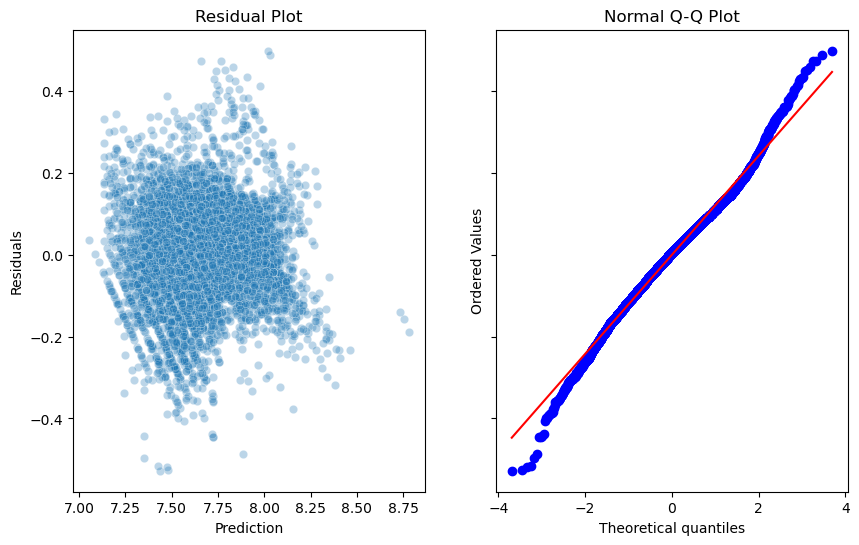

In [37]:
residual_analysis_plots(model);

### Outliers & Influence

In [39]:
influence = model.get_influence()
inf_summary_df = influence.summary_frame()
inf_summary_df.head()

,dfb_const,dfb_ram,dfb_speed,dfb_hd,dfb_screen,dfb_ads,dfb_trend,dfb_premium_flag,dfb_multi_flag,dfb_cd_flag,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,-0.031107,-0.002426,0.018723,0.011866,0.006568,0.069735,0.039293,-0.005979,-0.001036,-0.001036,0.000888,-2.187117,0.001853,-0.094236,-2.187779,-0.094264
1,-0.008882,0.004380,0.002158,-0.000262,0.001910,0.019871,0.013942,-0.001757,-0.000397,-0.000397,0.000076,-0.641810,0.001830,-0.027482,-0.641780,-0.027481
2,-0.002154,0.016530,0.026199,-0.007573,-0.027016,0.072852,0.056289,-0.005867,-0.003368,-0.003368,0.001117,-2.388615,0.001953,-0.105672,-2.389514,-0.105712
3,-0.080874,-0.038290,0.020520,0.015479,0.018515,0.119819,0.075511,0.140450,-0.020998,-0.020998,0.003967,-3.244235,0.003755,-0.199179,-3.246710,-0.199331
4,0.018876,0.029727,-0.005554,-0.016886,-0.008500,-0.034100,-0.020308,-0.002204,0.000877,0.000877,0.000305,1.096932,0.002532,0.055269,1.096950,0.055270


In [29]:
inf_summary_df['cooks_d'].sort_values(ascending=False).head()

3783    0.038463
4477    0.030418
5960    0.019192
6225    0.009012
79      0.006465
Name: cooks_d, dtype: float64

### Multicollinearity

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
variables = sm.OLS(y, X).exog

pd.Series(
    [vif(variables, i) for i in range(variables.shape[1])],
    index=X.columns
)

C:\Users\TAJ\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


const           298.098567
ram               2.890987
speed             1.263162
hd                4.144819
screen            1.081616
ads               1.177681
trend             1.919357
premium_flag      1.089508
multi_flag             inf
cd_flag                inf
dtype: float64

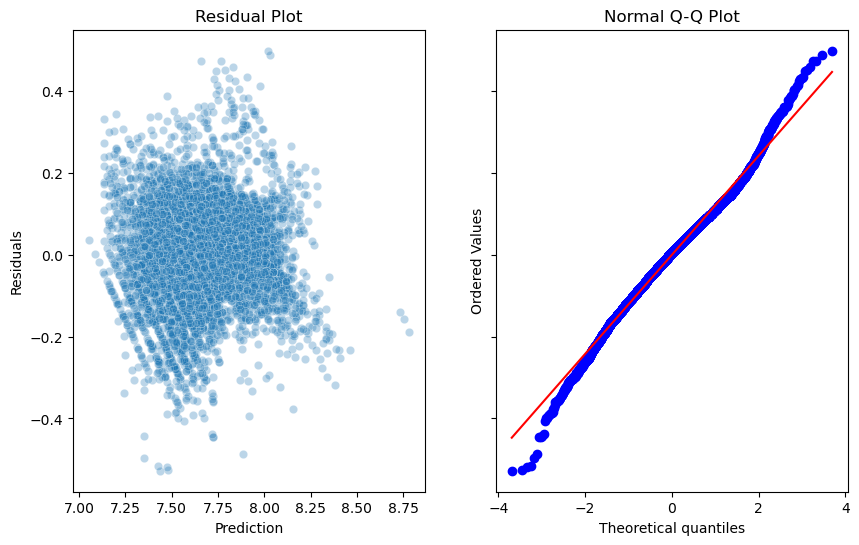

In [43]:
residual_analysis_plots(model);